<a href="https://colab.research.google.com/github/Ronaa-MX/simulacion-esfm/blob/simulacion-I/Ejemplo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Máquinas averíadas

In [1]:
# Librerías a usar
import random as rd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plot
from multiprocessing import Pool, cpu_count
import time

In [2]:
# ------------------------------------------------------------
# 1-3. Variables, probabilidades y CDFs
# ------------------------------------------------------------
tiempos_ind = np.array([20, 30, 40, 50, 60, 70, 80])
probs_ind   = np.array([0.05, 0.15, 0.15, 0.20, 0.20, 0.15, 0.10])
tiempos_grupo = np.array([30, 40, 50, 60, 70, 80, 90])
probs_grupo   = np.array([0.05, 0.15, 0.15, 0.20, 0.20, 0.15, 0.10])

cdf_ind = np.cumsum(probs_ind)
cdf_grupo = np.cumsum(probs_grupo)

In [3]:
# ------------------------------------------------------------
# 4. Generación vectorizada de tiempos
# ------------------------------------------------------------
def generar_tiempos(n, tiempos, cdf):
    u = np.random.uniform(0, 1, n)
    idx = np.searchsorted(cdf, u)
    return tiempos[idx]

In [4]:
# ------------------------------------------------------------
# 5. Experimento: simular N ciclos y devolver coste medio por hora
# ------------------------------------------------------------
def simular_politica(tiempos, cdf, t_repara, n_herramientas, n_ciclos):
    t_ops = generar_tiempos(n_ciclos, tiempos, cdf)
    tiempo_total = np.sum(t_ops) + n_ciclos * t_repara
    coste_total = 100 * n_ciclos * t_repara + n_herramientas * 10 * n_ciclos
    return coste_total / tiempo_total

In [5]:
# ------------------------------------------------------------
# 6. Función para obtener la evolución del coste medio acumulado (convergencia)
#    Simula una secuencia larga y calcula el promedio acumulado ciclo a ciclo.
# ------------------------------------------------------------
def obtener_convergencia(tiempos, cdf, t_repara, n_herramientas, max_ciclos, paso=10000):
    """
    Retorna dos listas:
        - ciclos: número de ciclos en cada punto de medición
        - costes_medios: coste medio por hora acumulado hasta ese ciclo
    """
    t_ops = generar_tiempos(max_ciclos, tiempos, cdf)
    tiempo_acum = 0.0
    coste_acum = 0.0
    ciclos_medidos = []
    costes_medios = []
    
    for i in range(max_ciclos):
        tiempo_acum += t_ops[i] + t_repara
        coste_acum += 100 * t_repara + n_herramientas * 10
        if (i+1) % paso == 0:
            ciclos_medidos.append(i+1)
            costes_medios.append(coste_acum / tiempo_acum)
    return ciclos_medidos, costes_medios

In [6]:
# ------------------------------------------------------------
# Parámetros globales
# ------------------------------------------------------------
N_CICLOS_POR_EXP = 1000000   # ciclos por experimento (precisión interna)
N_EXPERIMENTOS = 1000          # número de experimentos (para distribución)
MAX_CICLOS_CONV = 500_000      # ciclos para gráfico de convergencia
PASO_CONV = 1000             # cada cuántos ciclos guardamos un punto

In [7]:
# ------------------------------------------------------------
# 7. Simulaciones en paralelo de múltiples experimentos
# ------------------------------------------------------------
def simulacion_paralela(politica, n_ciclos_por_exp, n_experimentos):
    """
    politica: 'ind' o 'grupo'
    Retorna array de costes medios por hora (un valor por experimento)
    """
    if politica == 'ind':
        args = [(tiempos_ind, cdf_ind, 1, 1, n_ciclos_por_exp)] * n_experimentos
    else:
        args = [(tiempos_grupo, cdf_grupo, 2, 5, n_ciclos_por_exp)] * n_experimentos
    
    with Pool(processes=cpu_count()) as pool:
        resultados = pool.starmap(simular_politica, args)
    return np.array(resultados)

Ejecutando 1000 experimentos con 1000000 ciclos cada uno...


Tiempo total: 66.70 s


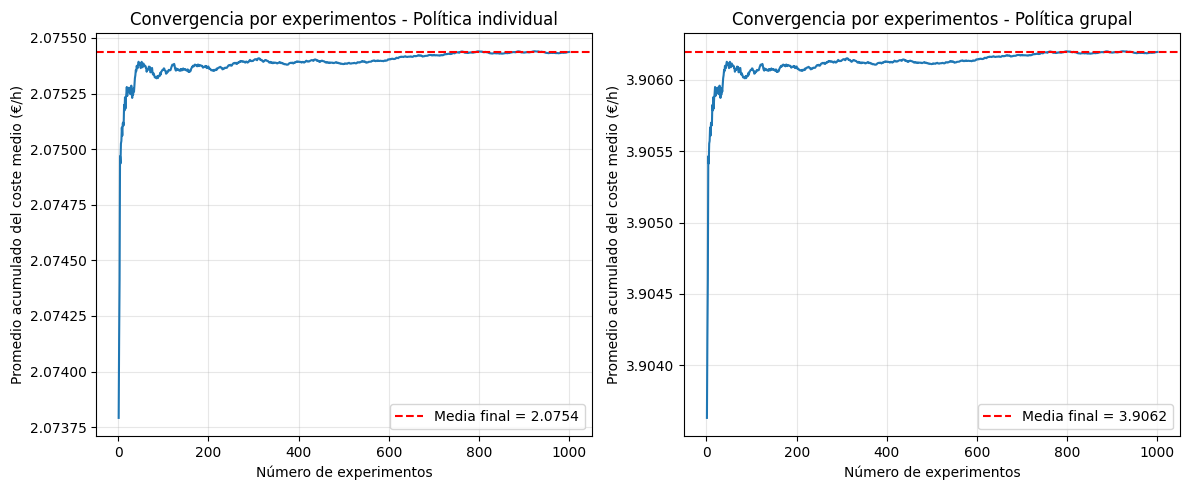


===== RESULTADOS =====
Individual: media = 2.08 €/h, std = 0.000639, var = 0.000000
  IC 95% media: (2.07, 2.08)
Grupal: media = 3.91 €/h, std = 0.000996, var = 0.000001
  IC 95% media: (3.90, 3.91)


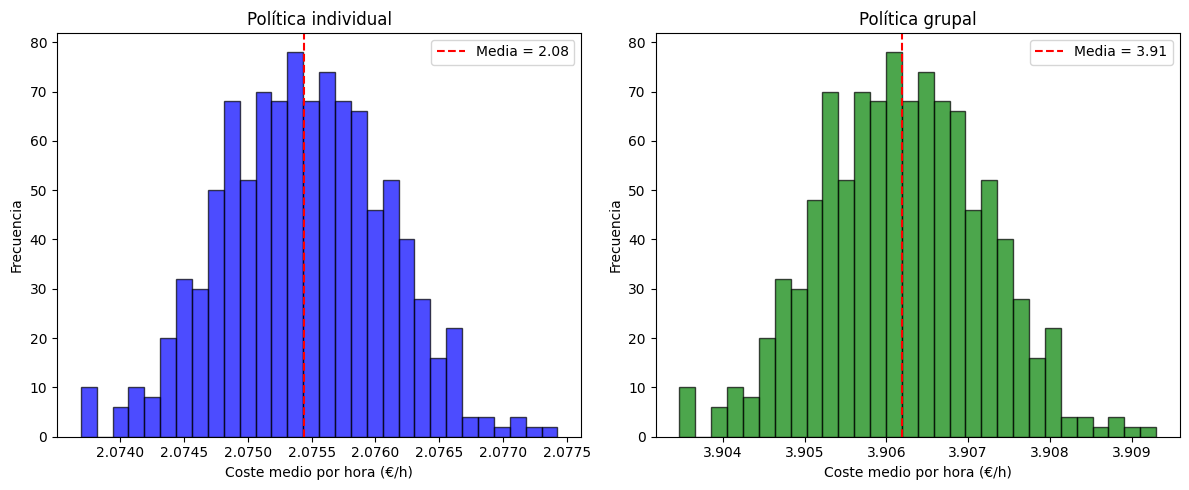

In [8]:
# ------------------------------------------------------------
# Ejecución principal
# ------------------------------------------------------------
if __name__ == "__main__":
      # 1. Simulación paralela
    print(f"Ejecutando {N_EXPERIMENTOS} experimentos con {N_CICLOS_POR_EXP} ciclos cada uno...")
    inicio = time.time()
    res_ind = simulacion_paralela('ind', N_CICLOS_POR_EXP, N_EXPERIMENTOS)
    res_grupo = simulacion_paralela('grupo', N_CICLOS_POR_EXP, N_EXPERIMENTOS)
    print(f"Tiempo total: {time.time()-inicio:.2f} s")

    # 2. Convergencia en función del número de experimentos (promedio acumulado)
    prom_acum_ind = np.cumsum(res_ind) / np.arange(1, N_EXPERIMENTOS+1)
    prom_acum_grupo = np.cumsum(res_grupo) / np.arange(1, N_EXPERIMENTOS+1)

    # Gráfico de convergencia por experimentos
    plot.figure(figsize=(12,5))
    plot.subplot(1,2,1)
    plot.plot(range(1, N_EXPERIMENTOS+1), prom_acum_ind, linewidth=1.5)
    plot.axhline(y=prom_acum_ind[-1], color='r', linestyle='--', label=f'Media final = {prom_acum_ind[-1]:.4f}')
    plot.xlabel('Número de experimentos')
    plot.ylabel('Promedio acumulado del coste medio (€/h)')
    plot.title('Convergencia por experimentos - Política individual')
    plot.legend()
    plot.grid(alpha=0.3)

    plot.subplot(1,2,2)
    plot.plot(range(1, N_EXPERIMENTOS+1), prom_acum_grupo, linewidth=1.5)
    plot.axhline(y=prom_acum_grupo[-1], color='r', linestyle='--', label=f'Media final = {prom_acum_grupo[-1]:.4f}')
    plot.xlabel('Número de experimentos')
    plot.ylabel('Promedio acumulado del coste medio (€/h)')
    plot.title('Convergencia por experimentos - Política grupal')
    plot.legend()
    plot.grid(alpha=0.3)
    plot.tight_layout()
    plot.show()
    # 9. Estadísticos
    media_ind, std_ind, var_ind = np.mean(res_ind), np.std(res_ind), np.var(res_ind)
    media_grupo, std_grupo, var_grupo = np.mean(res_grupo), np.std(res_grupo), np.var(res_grupo)
    alpha = 0.95
    
    # 10. Intervalos de confianza
    ic_ind = st.norm.interval(alpha,loc=media_ind,scale=std_ind)
    ic_grupo = st.norm.interval(alpha,loc=media_grupo,scale=std_grupo) 
    
    print("\n===== RESULTADOS =====")
    print(f"Individual: media = {media_ind:.2f} €/h, std = {std_ind:.6f}, var = {var_ind:.6f}")
    print(f"  IC 95% media: ({ic_ind[0]:.2f}, {ic_ind[1]:.2f})")
    print(f"Grupal: media = {media_grupo:.2f} €/h, std = {std_grupo:.6f}, var = {var_grupo:.6f}")
    print(f"  IC 95% media: ({ic_grupo[0]:.2f}, {ic_grupo[1]:.2f})")
    
    # 8. Histogramas
    plot.figure(figsize=(12,5))
    plot.subplot(1,2,1)
    plot.hist(res_ind, bins=30, alpha=0.7, color='blue', edgecolor='black')
    plot.axvline(media_ind, color='red', linestyle='--', label=f'Media = {media_ind:.2f}')
    plot.xlabel('Coste medio por hora (€/h)'); plot.ylabel('Frecuencia')
    plot.title('Política individual'); plot.legend()
    
    plot.subplot(1,2,2)
    plot.hist(res_grupo, bins=30, alpha=0.7, color='green', edgecolor='black')
    plot.axvline(media_grupo, color='red', linestyle='--', label=f'Media = {media_grupo:.2f}')
    plot.xlabel('Coste medio por hora (€/h)'); plot.ylabel('Frecuencia')
    plot.title('Política grupal'); plot.legend()
    plot.tight_layout()
    plot.show()